In [58]:
import subprocess
import sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for pkg in ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "flask"]:
    install(pkg)
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import pickle


### 1. Fungsi Grading

This section defines the `get_level(score)` function, which categorizes a student's total score into performance levels: "Basic", "Intermediate", "Proficient", and "Advanced". It also demonstrates this grading scale 
1. Fungsi Grading
This section defines the get_level(score) function, which categorizes a student's total score into performance levels: "Basic", "Intermediate", "Proficient", and "Advanced". It also demonstrates this grading scale with example scores.

In [59]:
def get_level(score):
    """
    EPrT Grading Scale (out of 30):
      0–12  → Basic
      13–20 → Intermediate
      21–26 → Proficient
      27–30 → Advanced
    """
    if score <= 12:
        return "Basic"
    elif score <= 20:
        return "Intermediate"
    elif score <= 26:
        return "Proficient"
    else:
        return "Advanced"

# Verify grading
print("=" * 50)
print("EPrT GRADING SCALE VERIFICATION")
print("=" * 50)
test_scores = [0, 5, 12, 13, 17, 20, 21, 24, 26, 27, 29, 30]
for s in test_scores:
    print(f"  Score {s:2d}/30 → {get_level(s)}")

EPrT GRADING SCALE VERIFICATION
  Score  0/30 → Basic
  Score  5/30 → Basic
  Score 12/30 → Basic
  Score 13/30 → Intermediate
  Score 17/30 → Intermediate
  Score 20/30 → Intermediate
  Score 21/30 → Proficient
  Score 24/30 → Proficient
  Score 26/30 → Proficient
  Score 27/30 → Advanced
  Score 29/30 → Advanced
  Score 30/30 → Advanced


2. Generate Data Sintetis
This section generates synthetic student data to simulate an English Proficiency Test (EPrT). It includes functions to generate scores for grammar, listening, and reading based on predefined difficulty levels, and then creates a DataFrame with these scores and their corresponding performance levels. This data can be replaced with real database data later.

In [60]:
np.random.seed(42)
N = 500  # number of synthetic students

def generate_student(level):
    """Generate realistic section scores per level."""
    if level == "Basic":
        # Total ~0–12, distributed across 3 sections
        g = np.random.randint(0, 5)
        l = np.random.randint(0, 5)
        r = np.random.randint(0, 4)
    elif level == "Intermediate":
        g = np.random.randint(3, 8)
        l = np.random.randint(3, 8)
        r = np.random.randint(3, 7)
    elif level == "Proficient":
        g = np.random.randint(6, 10)
        l = np.random.randint(6, 10)
        r = np.random.randint(5, 9)
    else:  # Advanced
        g = np.random.randint(8, 11)
        l = np.random.randint(8, 11)
        r = np.random.randint(8, 10)
    return g, l, r

# Distribution based on EPrT priors: Basic=35%, Inter=35%, Prof=20%, Adv=10%
level_distribution = {
    "Basic": int(N * 0.35),
    "Intermediate": int(N * 0.35),
    "Proficient": int(N * 0.20),
    "Advanced": int(N * 0.10),
}

records = []
for level, count in level_distribution.items():
    for _ in range(count):
        g, l, r = generate_student(level)
        total = g + l + r
        actual_level = get_level(total)  # re-label based on actual total
        records.append({
            "grammar": g,
            "listening": l,
            "reading": r,
            "total_score": total,
            "level": actual_level
        })

df = pd.DataFrame(records)
df["level"] = df["total_score"].apply(get_level)  # ensure correct labels

print("\n" + "=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nLevel distribution:")
print(df["level"].value_counts())


DATASET OVERVIEW
   grammar  listening  reading  total_score  level
0        3          4        2            9  Basic
1        2          4        0            6  Basic
2        1          2        2            5  Basic
3        2          2        3            7  Basic
4        4          3        3           10  Basic
5        2          4        1            7  Basic
6        3          1        3            7  Basic
7        3          4        0            7  Basic
8        3          1        1            5  Basic
9        4          3        0            7  Basic

Shape: (500, 5)

Level distribution:
level
Basic           209
Intermediate    170
Proficient       96
Advanced         25
Name: count, dtype: int64


3. Visualisasi Distribusi Skor per Level
This section visualizes the distribution of scores for each section (grammar, listening, reading) across the different performance levels using histograms. This helps in understanding how scores are distributed for Basic, Intermediate, Proficient, and Advanced students.

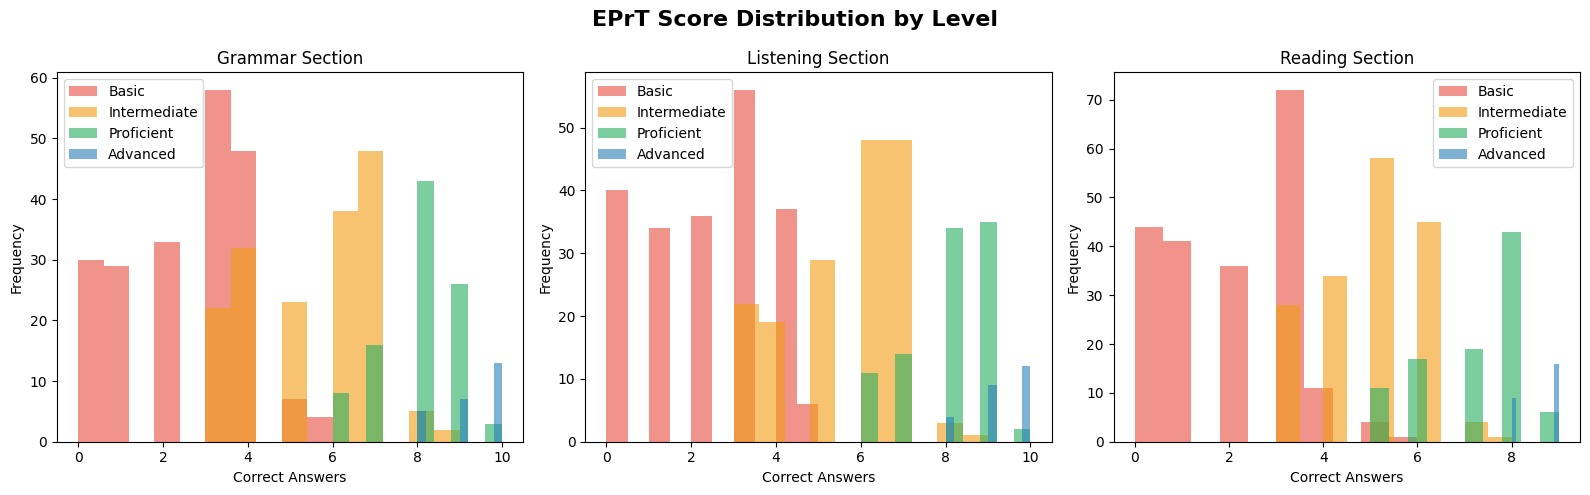

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EPrT Score Distribution by Level", fontsize=16, fontweight="bold")

level_order = ["Basic", "Intermediate", "Proficient", "Advanced"]
colors = ["#E74C3C", "#F39C12", "#27AE60", "#2980B9"]

for i, section in enumerate(["grammar", "listening", "reading"]):
    for j, level in enumerate(level_order):
        subset = df[df["level"] == level][section]
        axes[i].hist(subset, alpha=0.6, label=level, color=colors[j], bins=10)
    axes[i].set_title(f"{section.capitalize()} Section")
    axes[i].set_xlabel("Correct Answers")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

4. Split Train/Test 80:20 dengan Stratify
This section prepares the data for model training by splitting it into training and testing sets. It uses an 80:20 ratio for the split and applies stratification to ensure that the proportion of each performance level is maintained in both the training and testing datasets. It also encodes the categorical 'level' labels into numerical format using LabelEncoder.

In [62]:
features = ["grammar", "listening", "reading", "total_score"]
X = df[features].values
y = df["level"].values

le = LabelEncoder()
le.fit(level_order)  # ensure correct order
y_encoded = le.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n" + "=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"  Training samples : {len(X_train)}")
print(f"  Testing samples  : {len(X_test)}")


TRAIN / TEST SPLIT
  Training samples : 400
  Testing samples  : 100


5. Training Gaussian Naive Bayes + Laporan Akurasi
Here, a Gaussian Naive Bayes classifier is trained using the prepared training data. After training, it makes predictions on the test set, and the model's performance is evaluated using accuracy score and a detailed classification report, which includes precision, recall, and F1-score for each class.

In [63]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("GAUSSIAN NAIVE BAYES RESULTS")
print("=" * 50)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))


GAUSSIAN NAIVE BAYES RESULTS

Accuracy: 0.9400 (94.00%)

Classification Report:
              precision    recall  f1-score   support

    Advanced       1.00      1.00      1.00         5
       Basic       1.00      0.93      0.96        42
Intermediate       0.91      0.91      0.91        34
  Proficient       0.86      1.00      0.93        19

    accuracy                           0.94       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.94      0.94      0.94       100



6. Confusion Matrix
This section generates and displays a confusion matrix. The confusion matrix provides a visual representation of the model's performance, showing the number of correct and incorrect predictions for each performance level, helping to identify where the model might be struggling.

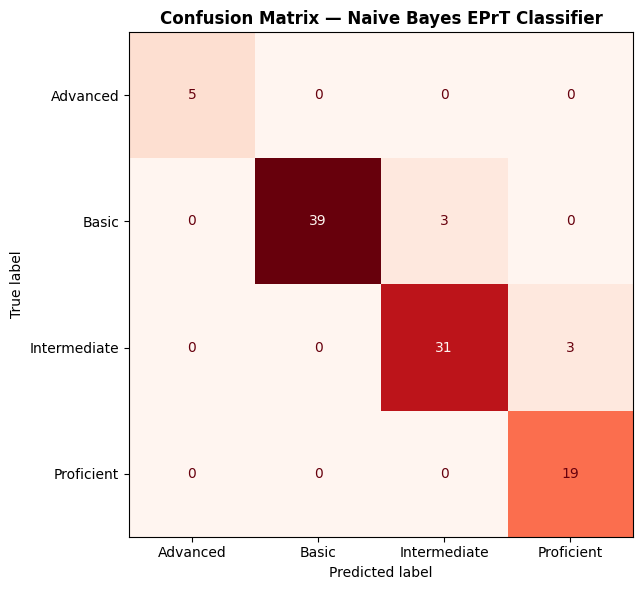

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Reds", colorbar=False)
ax.set_title("Confusion Matrix — Naive Bayes EPrT Classifier", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

7. Cross-Validation 5-Fold
This section performs a 5-fold stratified cross-validation on the Gaussian Naive Bayes model. Cross-validation helps to assess the model's generalization ability by training and testing it on different subsets of the data, providing a more robust estimate of its performance (mean accuracy and standard deviation).

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gnb, X, y_encoded, cv=cv, scoring="accuracy")

print("\n" + "=" * 50)
print("CROSS VALIDATION (5-Fold)")
print("=" * 50)
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"\n  Mean Accuracy : {cv_scores.mean():.4f}")
print(f"  Std Deviation : {cv_scores.std():.4f}")


CROSS VALIDATION (5-Fold)
  Fold 1: 0.9700
  Fold 2: 0.9400
  Fold 3: 0.9300
  Fold 4: 0.9000
  Fold 5: 0.9700

  Mean Accuracy : 0.9420
  Std Deviation : 0.0264



### 8. Prior Probability yang Dipelajari Model

This section displays the class prior probabilities learned by the Gaussian Naive Bayes model. These probabilities represent the initial likelihood of each performance level occurring in the dataset, which the model uses as a baseline for its predictions.
8. Prior Probability yang Dipelajari Model

In [66]:
print("\n" + "=" * 50)
print("CLASS PRIOR PROBABILITIES (learned)")
print("=" * 50)
for cls, prob in zip(le.classes_, gnb.class_prior_):
    print(f"  P({cls:15s}) = {prob:.4f}")


CLASS PRIOR PROBABILITIES (learned)
  P(Advanced       ) = 0.0500
  P(Basic          ) = 0.4175
  P(Intermediate   ) = 0.3400
  P(Proficient     ) = 0.1925


9. Fungsi predict_student() Siap Pakai


In [67]:
COURSE_CATALOG = {
    "grammar": {
        "Basic":        {"title": "Grammar 1", "description": "Pengenalan dasar struktur kalimat bahasa Inggris", "materials": ["Articles & Nouns", "Possessive Adjectives", "Present Simple", "Conjunctions dasar"], "total": 10, "section": "Section Grammar"},
        "Intermediate": {"title": "Grammar 2", "description": "Penguatan tata bahasa tingkat menengah", "materials": ["Passive Voice", "Conditionals Type 1 & 2", "Relative Clauses", "Modal Verbs"], "total": 12, "section": "Section Grammar"},
        "Proficient":   {"title": "Grammar 3", "description": "Tata bahasa kompleks untuk kebutuhan akademik", "materials": ["Complex Sentences", "Clauses & Phrases", "Inversion & Emphasis", "Academic Grammar"], "total": 15, "section": "Section Grammar"},
        "Advanced":     {"title": "Grammar 4", "description": "Penguasaan grammar tingkat lanjut", "materials": ["Subjunctive Mood", "Conditionals Type 3", "Concession Clauses", "Indirect Questions"], "total": 15, "section": "Section Grammar"},
    },
    "listening": {
        "Basic":        {"title": "Listening 1", "description": "Pemahaman percakapan pendek bahasa Inggris", "materials": ["Short Conversations", "Understanding Detail", "Main Idea sederhana"], "total": 10, "section": "Section Listening"},
        "Intermediate": {"title": "Listening 2", "description": "Meningkatkan kemampuan memahami spoken English", "materials": ["Longer Dialogues", "Different Accents", "Listening for Specific Info"], "total": 12, "section": "Section Listening"},
        "Proficient":   {"title": "Listening 3", "description": "Pemahaman listening akademik dan formal", "materials": ["Long Talks & Lectures", "Implied Meaning", "Inference dari Audio"], "total": 12, "section": "Section Listening"},
        "Advanced":     {"title": "Listening 4", "description": "Listening tingkat lanjut untuk EPrT", "materials": ["Academic Lectures", "Complex Dialogues", "Note-taking Strategies"], "total": 15, "section": "Section Listening"},
    },
    "reading": {
        "Basic":        {"title": "Reading 1", "description": "Memahami teks bahasa Inggris sederhana", "materials": ["Short Texts", "Basic Vocabulary", "Identifying Main Idea"], "total": 10, "section": "Section Reading"},
        "Intermediate": {"title": "Reading 2", "description": "Pemahaman bacaan tingkat menengah", "materials": ["Skimming & Scanning", "Vocabulary in Context", "Pronoun Reference"], "total": 12, "section": "Section Reading"},
        "Proficient":   {"title": "Reading 3", "description": "Analisis teks akademik", "materials": ["Making Inferences", "Negative Fact/Detail", "Determining Tone"], "total": 12, "section": "Section Reading"},
        "Advanced":     {"title": "Reading 4", "description": "Reading tingkat lanjut untuk EPrT", "materials": ["Complex Academic Texts", "Critical Analysis", "Author's Purpose"], "total": 15, "section": "Section Reading"},
    },
}

TOPIC_RECOMMENDATIONS = {
    "grammar": {
        "Basic":        ["Articles & Nouns", "Possessive Adjectives", "Subject-Verb Agreement"],
        "Intermediate": ["Passive Voice", "Conditionals", "Modal Verbs"],
        "Proficient":   ["Complex Sentences", "Inversion", "Academic Grammar"],
        "Advanced":     ["Subjunctive Mood", "Conditionals Type 3", "Indirect Questions"],
    },
    "listening": {
        "Basic":        ["Short Conversations", "Understanding Detail"],
        "Intermediate": ["Longer Dialogues", "Listening for Specific Info"],
        "Proficient":   ["Long Talks", "Implied Meaning", "Inference"],
        "Advanced":     ["Academic Lectures", "Complex Dialogues"],
    },
    "reading": {
        "Basic":        ["Identifying Main Idea", "Basic Vocabulary"],
        "Intermediate": ["Skimming & Scanning", "Vocabulary in Context"],
        "Proficient":   ["Making Inferences", "Determining Tone"],
        "Advanced":     ["Critical Analysis", "Author's Purpose"],
    },
}

SPEED_TIPS = {
    "Relax":     "Fokus 1 topik per minggu, jangan terburu-buru.",
    "Moderate":  "Target selesai 2 topik per minggu dengan latihan soal rutin.",
    "Intensive": "Kerjakan minimal 30 soal per hari dan review kesalahan setiap sesi.",
}

In [68]:
def predict_student(grammar_correct, listening_correct, reading_correct,
                    speed="Moderate", hours_per_day=2, days_per_week=3):
    total   = grammar_correct + listening_correct + reading_correct
    X_input = np.array([[grammar_correct, listening_correct, reading_correct, total]])
 
    predicted_encoded = gnb.predict(X_input)[0]
    probabilities     = gnb.predict_proba(X_input)[0]
    level             = le.inverse_transform([predicted_encoded])[0]
    confidence        = probabilities[predicted_encoded]
 
    sections = {
        "grammar":   {"correct": grammar_correct,  "total": 10, "pct": grammar_correct  / 10 * 100},
        "listening": {"correct": listening_correct, "total": 10, "pct": listening_correct / 10 * 100},
        "reading":   {"correct": reading_correct,   "total": 10, "pct": reading_correct   / 10 * 100},
    }
    weak = [k for k, v in sections.items() if v["pct"] < 60]
 
    next_level_map   = {"Basic": 13, "Intermediate": 21, "Proficient": 27, "Advanced": 30}
    points_needed    = max(0, next_level_map[level] - total)
    speed_multiplier = {"Relax": 0.5, "Moderate": 1.0, "Intensive": 1.5}.get(speed, 1.0)
    effort           = hours_per_day * days_per_week * speed_multiplier
    est_weeks        = int(np.ceil(points_needed / effort)) if effort > 0 else 0
 
    kurang  = [topic for sec in weak for topic in TOPIC_RECOMMENDATIONS.get(sec, {}).get(level, [])]
    improve = [SPEED_TIPS.get(speed, "")]
 
    recommended_courses = []
    for sec in ["grammar", "listening", "reading"]:
        course             = COURSE_CATALOG[sec][level].copy()
        course["status"]   = "progress" if sec in weak else "available"
        course["progress"] = 0
        recommended_courses.append(course)
 
    return {
        "total_score":                   total,
        "total_questions":               30,
        "percentage":                    round(total / 30 * 100, 1),
        "level":                         level,
        "level_confidence":              round(float(confidence), 4),
        "all_probabilities":             {cls: round(float(p), 4) for cls, p in zip(le.classes_, probabilities)},
        "section_scores":                sections,
        "weak_sections":                 weak,
        "estimated_weeks_to_next_level": est_weeks,
        "weekly_study_hours":            hours_per_day * days_per_week,
        "recommendation": {
            "kurang":  kurang,
            "improve": improve,
        },
        "recommended_courses": recommended_courses,
    }

10. Demo 4 Student dari Tiap Level
This section demonstrates the predict_student() function by applying it to four hypothetical students representing different performance levels. It prints a detailed analysis for each student, including their predicted level, confidence, weak areas, and estimated time to reach the next level.

In [69]:
print("\nDEMO PREDICTIONS")
 
test_students = [
    {"name": "Student A (Basic)",        "g": 3, "l": 4,  "r": 2, "speed": "Moderate",  "h": 2, "d": 3},
    {"name": "Student B (Intermediate)", "g": 5, "l": 6,  "r": 5, "speed": "Intensive", "h": 3, "d": 4},
    {"name": "Student C (Proficient)",   "g": 8, "l": 7,  "r": 8, "speed": "Relax",     "h": 1, "d": 3},
    {"name": "Student D (Advanced)",     "g": 9, "l": 10, "r": 9, "speed": "Moderate",  "h": 2, "d": 5},
]
 
for s in test_students:
    result = predict_student(s["g"], s["l"], s["r"], s["speed"], s["h"], s["d"])
    print(f"\n  {s['name']}")
    print(f"    Score      : {result['total_score']}/30 ({result['percentage']}%)")
    print(f"    Level      : {result['level']} (confidence: {result['level_confidence']*100:.1f}%)")
    print(f"    Weak       : {result['weak_sections'] or 'None'}")
    print(f"    Kurang     : {result['recommendation']['kurang']}")
    print(f"    Tips       : {result['recommendation']['improve']}")
    print(f"    Est. Weeks : ~{result['estimated_weeks_to_next_level']} weeks")
    print(f"    Courses    : {[c['title'] for c in result['recommended_courses']]}")


DEMO PREDICTIONS

  Student A (Basic)
    Score      : 9/30 (30.0%)
    Level      : Basic (confidence: 100.0%)
    Weak       : ['grammar', 'listening', 'reading']
    Kurang     : ['Articles & Nouns', 'Possessive Adjectives', 'Subject-Verb Agreement', 'Short Conversations', 'Understanding Detail', 'Identifying Main Idea', 'Basic Vocabulary']
    Tips       : ['Target selesai 2 topik per minggu dengan latihan soal rutin.']
    Est. Weeks : ~1 weeks
    Courses    : ['Grammar 1', 'Listening 1', 'Reading 1']

  Student B (Intermediate)
    Score      : 16/30 (53.3%)
    Level      : Intermediate (confidence: 100.0%)
    Weak       : ['grammar', 'reading']
    Kurang     : ['Passive Voice', 'Conditionals', 'Modal Verbs', 'Skimming & Scanning', 'Vocabulary in Context']
    Tips       : ['Kerjakan minimal 30 soal per hari dan review kesalahan setiap sesi.']
    Est. Weeks : ~1 weeks
    Courses    : ['Grammar 2', 'Listening 2', 'Reading 2']

  Student C (Proficient)
    Score      : 23/30

11. Export .pkl untuk Dipakai di Flask/FastAPI

In [70]:
import pickle, os

with open("eprt_naive_bayes_model.pkl", "wb") as f:
    pickle.dump({"model": gnb, "label_encoder": le}, f)

print("\n" + "=" * 50)
print("MODEL EXPORTED")
print("=" * 50)
print("  File: eprt_naive_bayes_model.pkl")
print("  Use this model in a Python FastAPI/Flask backend")
print("  then call it from your Node.js via HTTP.")


MODEL EXPORTED
  File: eprt_naive_bayes_model.pkl
  Use this model in a Python FastAPI/Flask backend
  then call it from your Node.js via HTTP.


In [71]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    body = request.json
    result = predict_student(
        grammar_correct   = body["grammar_correct"],
        listening_correct = body["listening_correct"],
        reading_correct   = body["reading_correct"],
        speed             = body.get("speed", "Moderate"),
        hours_per_day     = body.get("hours_per_day", 2),
        days_per_week     = body.get("days_per_week", 3),
    )
    return jsonify(result)

app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [02/Jun/2026 04:29:59] "GET / HTTP/1.1" 404 -


2. Visualisasi Nilai Rata-rata per Fitur per Level (θ)

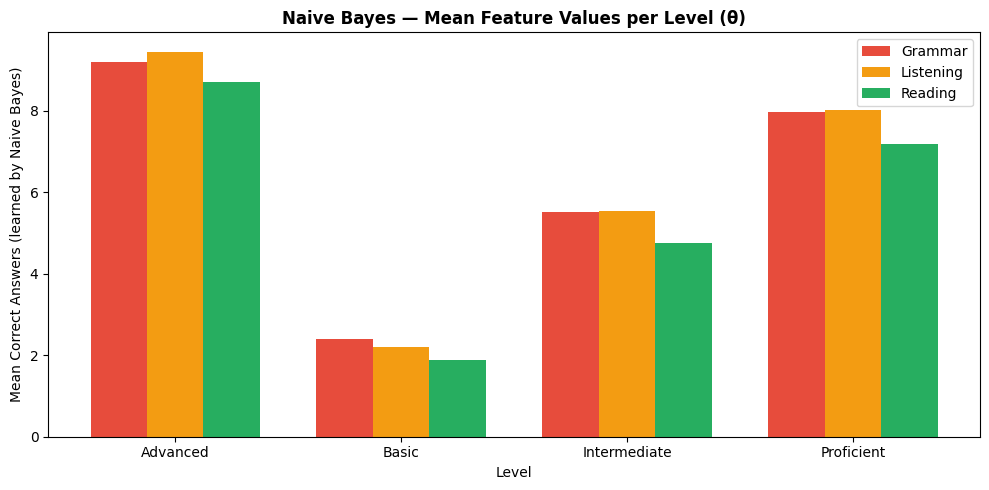


✅ Proses selesai! Model berhasil dilatih dan siap digunakan.
   File yang dihasilkan: score_distribution.png, confusion_matrix.png, feature_means.png
                          eprt_naive_bayes_model.pkl


In [72]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(le.classes_))
width = 0.25
feature_names = ["Grammar", "Listening", "Reading"]

for i, feat in enumerate(feature_names):
    means = [gnb.theta_[c][i] for c in range(len(le.classes_))]
    ax.bar(x + i * width, means, width, label=feat, color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(le.classes_)
ax.set_xlabel("Level")
ax.set_ylabel("Mean Correct Answers (learned by Naive Bayes)")
ax.set_title("Naive Bayes — Mean Feature Values per Level (θ)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("feature_means.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Proses selesai! Model berhasil dilatih dan siap digunakan.")
print("   File yang dihasilkan: score_distribution.png, confusion_matrix.png, feature_means.png")
print("                          eprt_naive_bayes_model.pkl")